In [1]:
import torch.nn as nn
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
mnist_transform = transforms.Compose([
        transforms.ToTensor(),
])

train_dataset = MNIST(root='./data', train=True, download=True, transform=mnist_transform)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True, num_workers=4)

test_dataset = MNIST(root='./data', train=False, download=True, transform=mnist_transform)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.78MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [3]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 64),
            nn.ReLU(),
        )
        
        self.fc_mu = nn.Linear(64, 2)
        self.fc_logvar = nn.Linear(64, 2)
        
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 128 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

        
    def forward(self, x):
        # encoder
        h = self.encoder(x)
        
        # latent distribution
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        # reparameterization trick
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = epsilon * std + mu 
        
        # decoder
        x = self.decoder(z)
        return x, mu, logvar
    
model = Model().to(device)
model(torch.rand(1, 1, 28, 28).to(device))
sum(p.numel() for p in model.parameters())

1016261

In [4]:
def display_images(x, x_hat):
    x = x.detach().cpu().squeeze().numpy()
    x_hat = x_hat.detach().cpu().squeeze().numpy()
    
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1); 
    plt.imshow(x, cmap="gray", vmin=0, vmax=1)
    plt.axis("off"); 
    plt.title("Input")
    
    plt.subplot(1, 2, 2); 
    plt.imshow(x_hat, cmap="gray", vmin=0, vmax=1)
    plt.axis("off"); 
    plt.title("Reconstruction")
    plt.tight_layout();
    plt.show()

In [5]:
def criterion(x, x_hat, mu, logvar, beta=1.0):
    bce = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)
    # direct formula of kl div between multivariate gaussian and standard gaussian
    kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return bce + beta * kl, bce, beta * kl

In [6]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
comb_loss = []
bce_loss = []
kl_loss = []

133it [00:01, 94.83it/s]

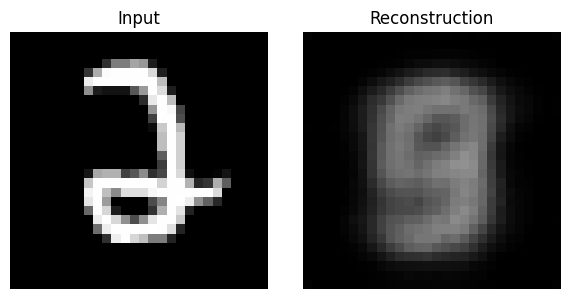

938it [00:11, 83.07it/s] 

171.54042106904964 166.93008206495597 4.61033902683609



635it [00:07, 66.74it/s] 

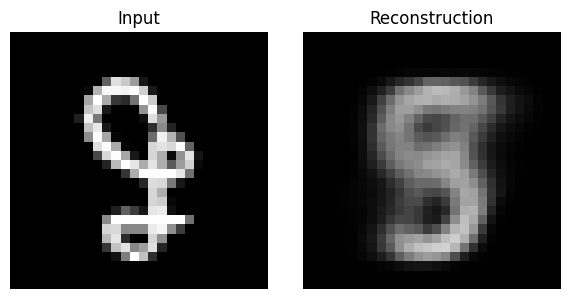

938it [00:10, 87.56it/s] 

155.52200431254371 149.92565387652627 5.596350505153762



844it [00:09, 60.59it/s]

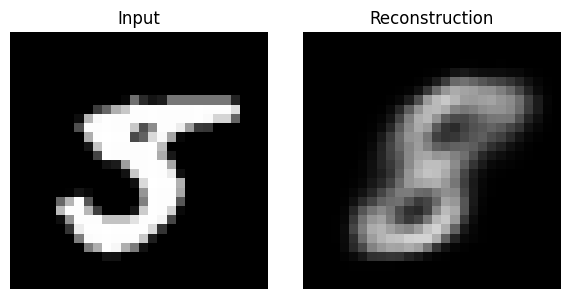

938it [00:10, 87.19it/s]

152.2048473236149 146.31119081053907 5.8936565786536566



355it [00:03, 95.12it/s]

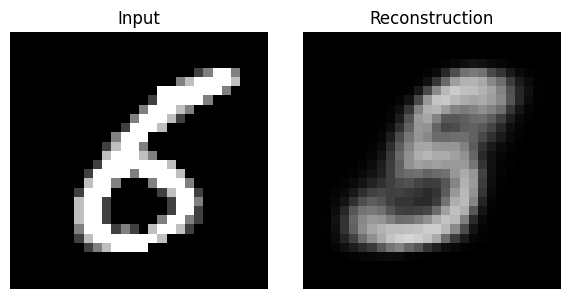

938it [00:10, 87.96it/s]

150.12120591348676 144.03101609154805 6.090189858031934



925it [00:09, 96.47it/s]

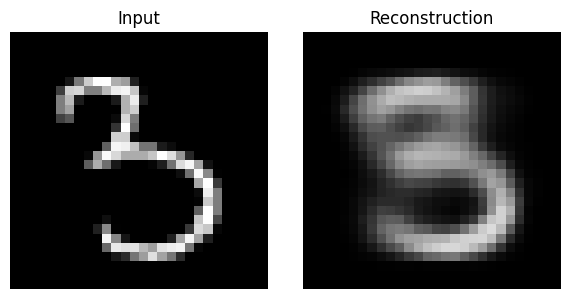

938it [00:10, 92.84it/s]

148.61877064816733 142.4157861087368 6.202984606025061



14it [00:00, 66.40it/s]

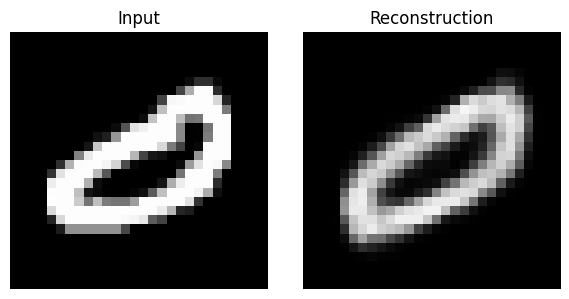

938it [00:10, 88.80it/s] 

147.5566321822372 141.2537290089166 6.302903233306495



339it [00:04, 88.62it/s]

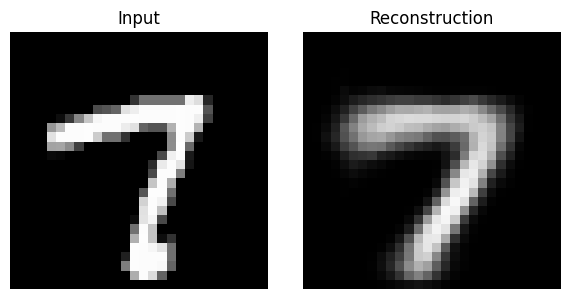

938it [00:10, 86.66it/s] 

146.71814249522652 140.3495452246432 6.36859730464309



764it [00:08, 97.53it/s] 

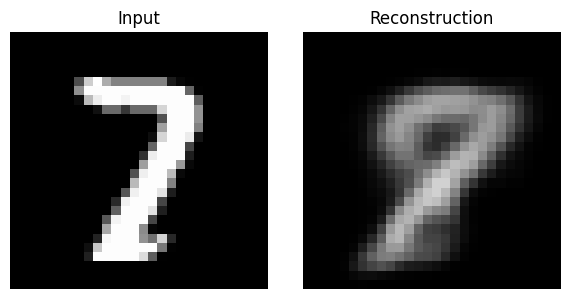

938it [00:10, 86.99it/s] 

145.9450478462268 139.50030608675374 6.444741673052692



921it [00:10, 82.44it/s]

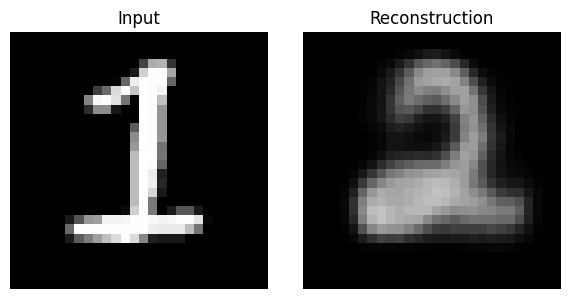

938it [00:10, 86.21it/s]

145.2970020155917 138.78349650694108 6.513505585412227



752it [00:08, 95.64it/s]

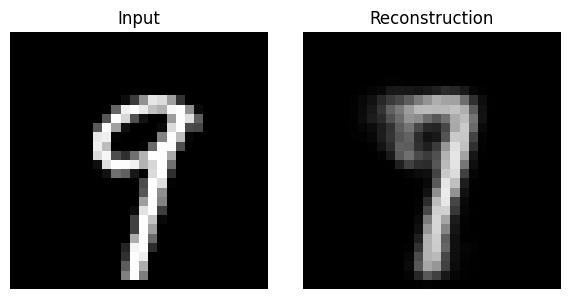

938it [00:10, 87.07it/s] 

144.6783811491944 138.1227314263773 6.555649792461761



519it [00:05, 97.06it/s] 

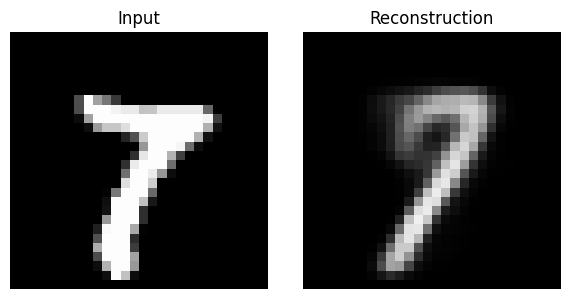

938it [00:10, 87.36it/s]

144.3112137231237 137.6882526015422 6.622961296455692



0it [00:00, ?it/s]

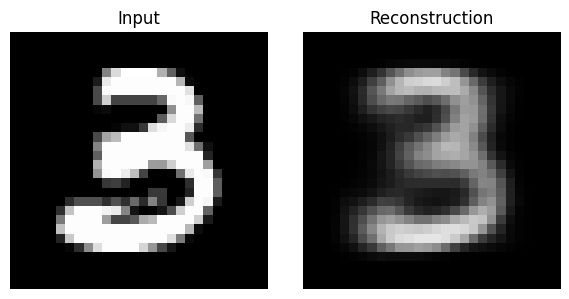

938it [00:11, 84.85it/s] 

143.75824970172158 137.11159829341017 6.646651613178538



471it [00:05, 95.69it/s] 

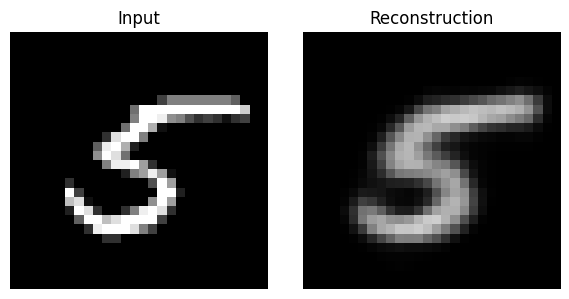

938it [00:10, 92.99it/s] 

143.3472954479616 136.6559043510128 6.691390878356088



252it [00:03, 95.65it/s]

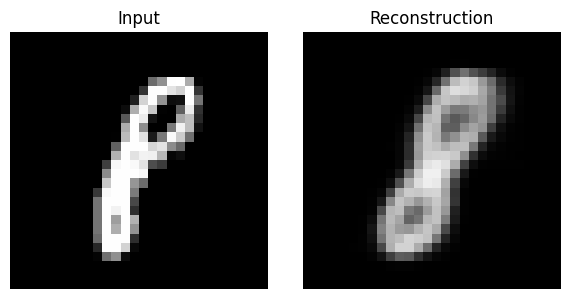

938it [00:10, 87.06it/s] 

142.9869120827616 136.27889958526026 6.708012664241831



391it [00:04, 94.61it/s]

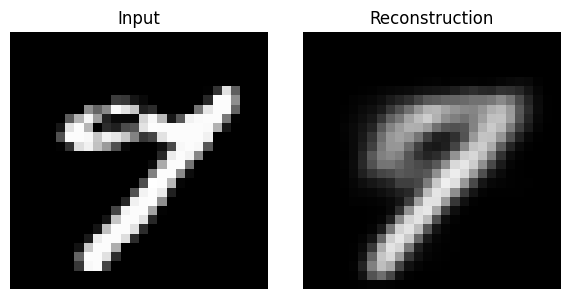

938it [00:10, 86.30it/s] 

142.7287489315594 135.9831570541935 6.745592012080048



115it [00:01, 98.46it/s]

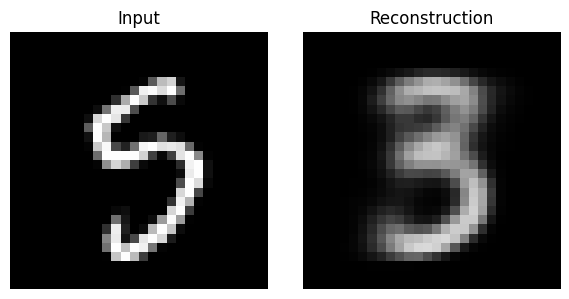

938it [00:10, 87.46it/s] 

142.33266200083912 135.55764973036517 6.775012432130923



137it [00:01, 97.03it/s]

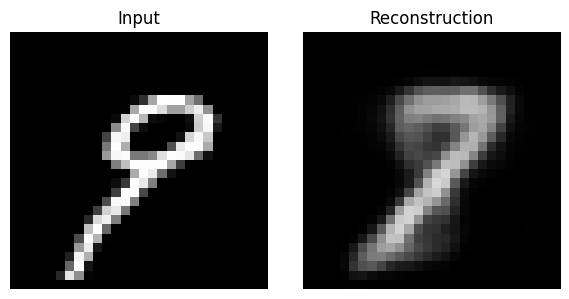

938it [00:10, 87.25it/s] 

142.04232932865492 135.22741843998304 6.814910997968239



190it [00:02, 95.81it/s]

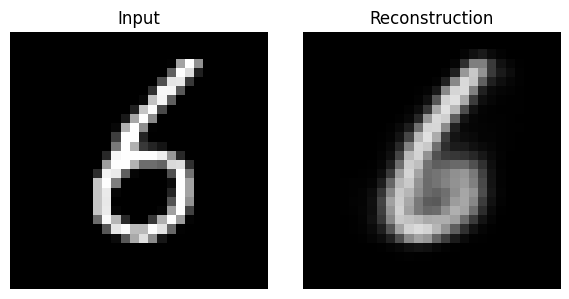

938it [00:10, 86.83it/s]

141.77404575307233 134.95475224899585 6.819293593546983



889it [00:10, 92.29it/s] 

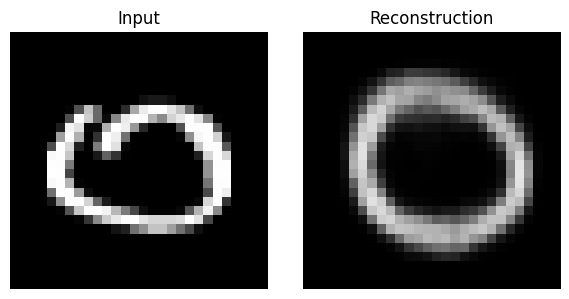

938it [00:10, 87.46it/s]

141.58565064127257 134.7309009495066 6.85474968058214



383it [00:04, 95.05it/s]

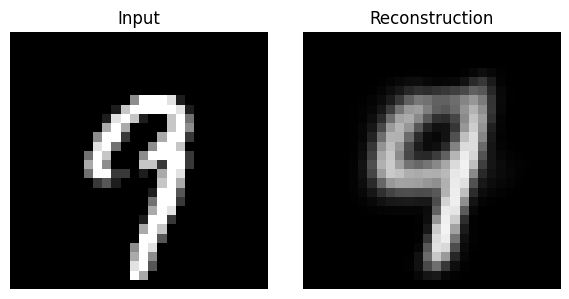

938it [00:10, 88.51it/s] 

141.2633877654574 134.4038963399208 6.85949138639324


In [7]:
for epoch in range(20):
    running_loss = 0.0
    running_bce = 0.0
    running_kl = 0.0
    r = random.randint(0, len(train_dataloader)) - 1
    
    model.train()
    for i, data in tqdm(enumerate(train_dataloader)):
        inputs, _ = data
        inputs = inputs.to(device)

        optimizer.zero_grad()

        outputs, mu, logvar = model(inputs)
        loss, bce, kl = criterion(inputs, outputs, mu, logvar)
        loss.backward()
        optimizer.step()
        
        if i == r:
            display_images(inputs[0], outputs[0])

        running_loss += loss.item()
        running_bce += bce.item()
        running_kl += kl.item()
    
    comb_loss.append(running_loss / len(train_dataloader))
    bce_loss.append(running_bce / len(train_dataloader))
    kl_loss.append(running_kl / len(train_dataloader))
    print(comb_loss[-1], bce_loss[-1], kl_loss[-1])

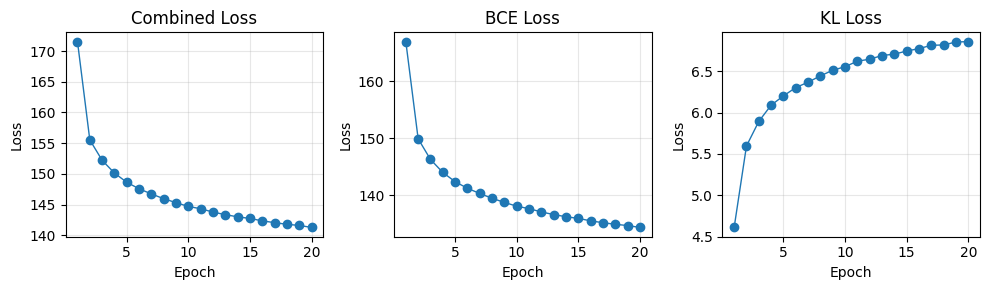

In [8]:
epochs = np.arange(1, len(comb_loss) + 1)
plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.plot(epochs, comb_loss, marker="o", linewidth=1)
plt.title("Combined Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(epochs, bce_loss, marker="o", linewidth=1)
plt.title("BCE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

# the KL loss keeps the latent constraint, and typically starts low
# (as untrained encoder outputs a distribution close to the prior)
# and then starts increasing as the model tries to reduce the reconstruction loss
plt.subplot(1, 3, 3)
plt.plot(epochs, kl_loss, marker="o", linewidth=1)
plt.title("KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

  7%|▋         | 11/157 [00:00<00:02, 55.22it/s]

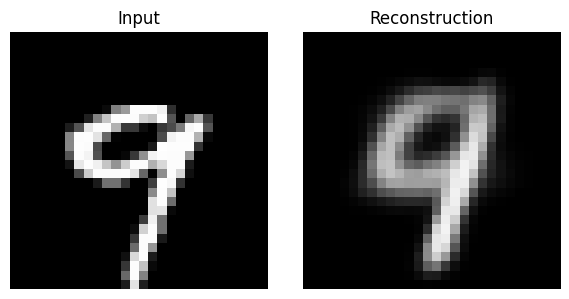

 44%|████▍     | 69/157 [00:00<00:00, 107.43it/s]

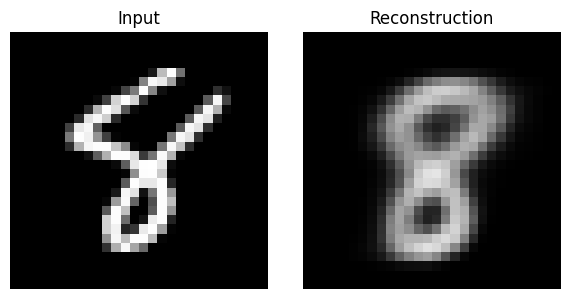

 61%|██████    | 95/157 [00:01<00:00, 98.19it/s] 

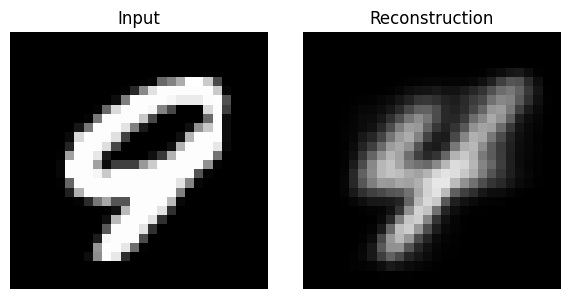

 85%|████████▍ | 133/157 [00:01<00:00, 98.42it/s]

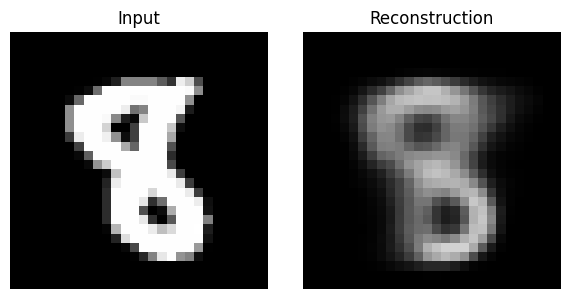

 92%|█████████▏| 144/157 [00:01<00:00, 82.47it/s]

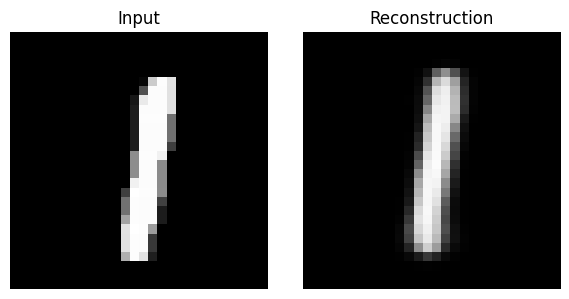

100%|██████████| 157/157 [00:01<00:00, 80.12it/s]


In [9]:
# generating test set reconstructions and saving latents in a dictionary for each label
d = {}
model.eval()
with torch.no_grad():
    r_list = random.sample(range(len(test_dataloader)), 5)
    for i, data in enumerate(tqdm(test_dataloader)):
        inputs, labels = data
        inputs = inputs.to(device)

        outputs, mu, logvar = model(inputs)
        
        if i in r_list:
            display_images(inputs[0], outputs[0])
        
        latents = mu.cpu().numpy()
        lbls = labels.numpy()
        
        for idx, label in enumerate(lbls):
            if label not in d:
                d[label] = []
            d[label].append(latents[idx])

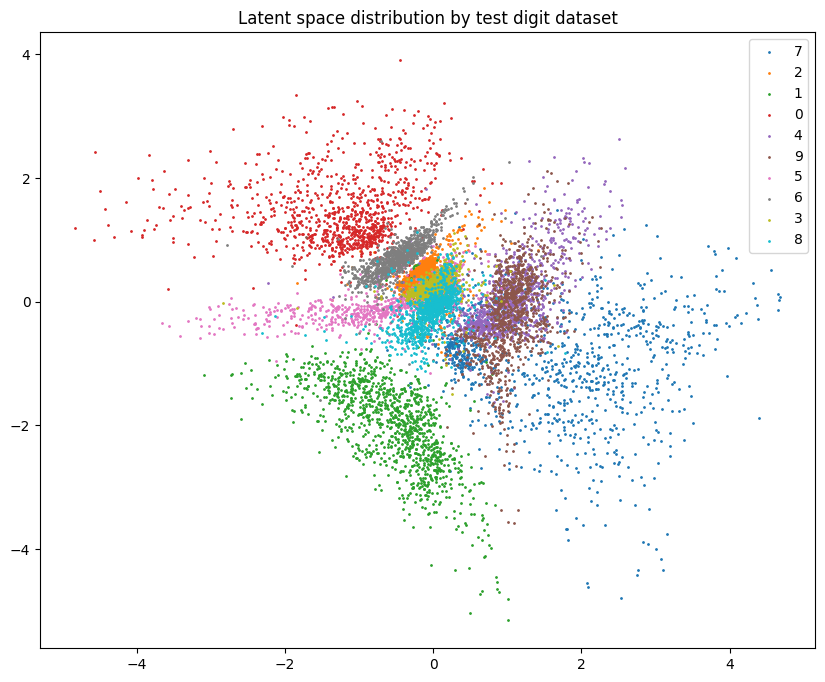

In [10]:
plt.figure(figsize=(10, 8))
for label, points in d.items():
    pts = np.array(points)
    plt.scatter(pts[:, 0], pts[:, 1], label=label, s=1)

plt.legend()
plt.title("Latent space distribution by test digit dataset")
plt.show()

In [ ]:
# we set z_2 to be 0, as we get the most diversity along that axis
# we vary z_1 by 0.05 between -2 and 3 to get 100 latent outputs

output_images = []
z_2 = 0

model.eval()
with torch.no_grad():
    for i in range(-40, 60):
        z_1 = i / 20
        z = torch.tensor([[z_1, z_2]], dtype=torch.float32).to(device)
        x = model.decoder(z)
        output_images.append(x.detach().cpu().squeeze().numpy())

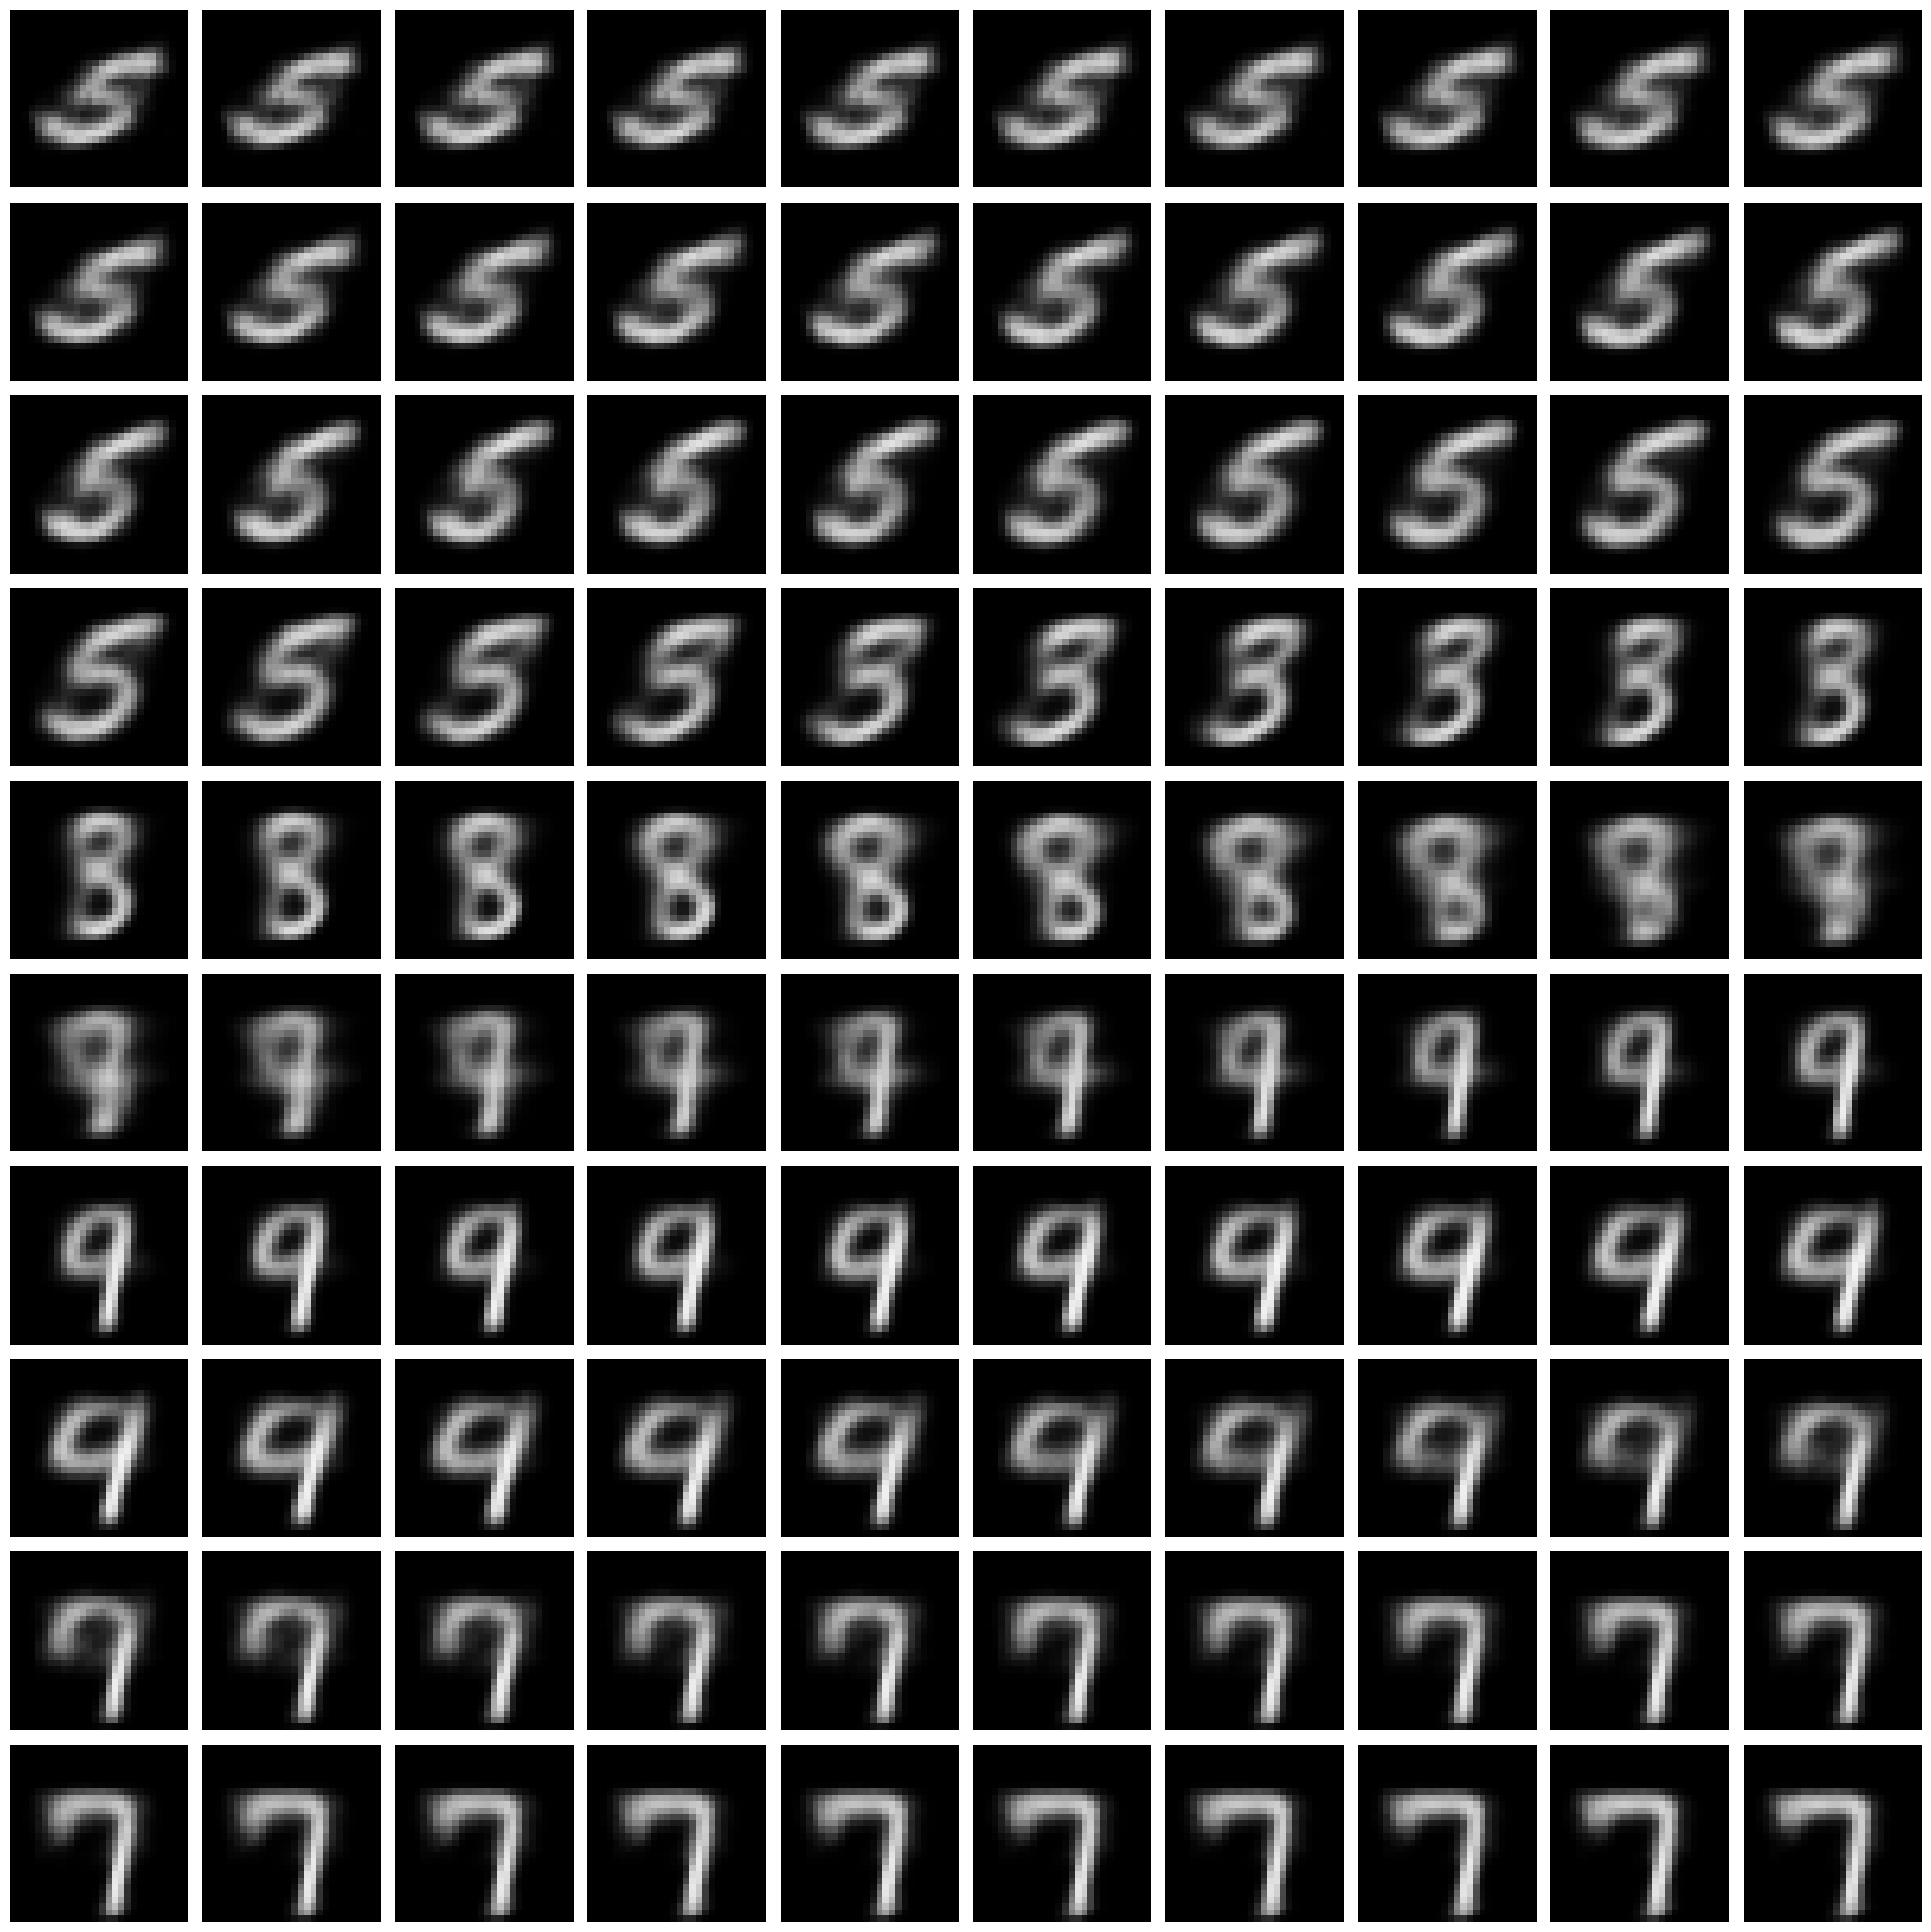

In [12]:
plt.figure(figsize=(20, 20))
for i, img in enumerate(output_images):
    plt.subplot(10, 10, i + 1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
plt.tight_layout()
plt.show()